<a href="https://colab.research.google.com/github/LiviaSilva22/Analise-Dados-Python/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Previsão da produção de soja na província de Tete
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

# Configuração dos gráficos
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 12

print("Configuração inicial concluída")

# Parâmetros
np.random.seed(42)
n_samples = 1000
anos = np.tile(np.arange(2000, 2024), 42)[:n_samples]

# Distribuções
area_plantada = np.random.normal(150, 50, n_samples)
area_plantada = np.clip(area_plantada, 20, 400)

# Chuva-média 800 mm
precipitacao = np.random.normal(800, 200, n_samples)
precipitacao = np.clip(precipitacao, 300, 1500)

# Temperatura média (°C) - média 26°C
temperatura_media = np.random.normal(26, 4, n_samples)
temperatura_media = np.clip(temperatura_media, 18, 35)

# Uso de fertilizantes (kg/ha)
uso_fertilizante = np.random.normal(180, 60, n_samples)
uso_fertilizante = np.clip(uso_fertilizante, 50, 350)

# Índice de vegetação (NDVI)
indice_vegetacao = np.random.normal(0.55, 0.1, n_samples)
indice_vegetacao = np.clip(indice_vegetacao, 0.2, 0.9)

# Variáveis temporais
mes_plantio = np.random.choice([10, 11, 12], n_samples)
dias_sem_chuva = np.random.poisson(15, n_samples)

# Função de produção
def calcular_producao(area, chuva, temp, fert, ndvi, mes):
    producao_base = 1.2 * area + 0.4 * fert + 250 * ndvi

    # efeito da chuva: ideal perto de 850 mm
    efeito_chuva = -0.0003 * (chuva - 850) ** 2 + 50

    # efeito da temperatura
    if temp < 20 or temp > 32:
        efeito_temp = -30
    elif temp < 24:
        efeito_temp = -10
    elif temp <= 30:
        efeito_temp = 20
    else:
        efeito_temp = -15

    # efeito do mês de plantio
    efeito_mes = {10: 40, 11: 60, 12: 20}[mes]

    # ruído: pragas, erro de medição, variações locais
    ruido = np.random.normal(0, 25)

    producao = producao_base + efeito_chuva + efeito_temp + efeito_mes + ruido
    return max(producao, 10)

# Gerar produção para cada linha
producao = []
for i in range(n_samples):
    p = calcular_producao(
        area_plantada[i],
        precipitacao[i],
        temperatura_media[i],
        uso_fertilizante[i],
        indice_vegetacao[i],
        mes_plantio[i]
    )
    producao.append(p)

# DataFrame final
df = pd.DataFrame({
    "Ano": anos,
    "Area_Plantada_ha": area_plantada,
    "Precipitacao_mm": precipitacao,
    "Temperatura_C": temperatura_media,
    "Fertilizante_Kg_ha": uso_fertilizante,
    "Indice_Vegetacao": indice_vegetacao,
    "Mes_Plantio": mes_plantio,
    "Dias_Sem_Chuva": dias_sem_chuva,
    "Producao_ton": producao
})

print("Dataset criado!")
print(f"Dimensões: {df.shape}")
print("\nPrimeiras linhas:")
print(df.head())

print("\nEstatísticas descritivas:")
print(df.describe())

Configuração inicial concluída
Dataset criado!
Dimensões: (1000, 9)

Primeiras linhas:
    Ano  Area_Plantada_ha  Precipitacao_mm  Temperatura_C  Fertilizante_Kg_ha  \
0  2000        174.835708      1079.871087      23.299287           65.531547   
1  2001        143.086785       984.926737      25.421925          128.376899   
2  2002        182.384427       811.926074      22.830320          155.183668   
3  2003        226.151493       670.612644      24.768154          293.261259   
4  2004        138.292331       939.644663      18.425541          213.393187   

   Indice_Vegetacao  Mes_Plantio  Dias_Sem_Chuva  Producao_ton  
0          0.463651           10               5    439.779486  
1          0.546880           11              19    476.664386  
2          0.551802           10              13    467.538357  
3          0.597263           11              15    690.209113  
4          0.413314           12              12    389.842236  

Estatísticas descritivas:
         

In [ ]:
df.isna().sum()

,0
Ano,0
Area_Plantada_ha,0
Precipitacao_mm,0
Temperatura_C,0
Fertilizante_Kg_ha,0
Indice_Vegetacao,0
Mes_Plantio,0
Dias_Sem_Chuva,0
Producao_ton,0


In [ ]:
# Separacao de variáveis
X = df.drop(columns=["Producao_ton"])
y = df["Producao_ton"]

print("\nVariáveis de entrada:")
print(X.columns.tolist())

print("\nDimensão de X:", X.shape)
print("Dimensão de y:", y.shape)


Variáveis de entrada:
['Ano', 'Area_Plantada_ha', 'Precipitacao_mm', 'Temperatura_C', 'Fertilizante_Kg_ha', 'Indice_Vegetacao', 'Mes_Plantio', 'Dias_Sem_Chuva']

Dimensão de X: (1000, 8)
Dimensão de y: (1000,)


In [ ]:
#Listas para guardar os erros de cada modelo
rf_100_res = []
rf_250_res = []
rf_500_res = []
lr_res = []
ridge_res = []
knn_3_res = []
knn_5_res = []
knn_7_res = []

In [ ]:
for i in range(15):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, shuffle=True, random_state=i
    )
    #Normalization
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    # Regressão Linear
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    pred_lr = lr.predict(X_test_scaled)
    error_lr = mean_squared_error(y_test, pred_lr)
    lr_res.append(error_lr)

    # Random Forest com 100 árvores
    rf_100 = RandomForestRegressor(n_estimators=100, random_state=i)
    rf_100.fit(X_train_scaled, y_train)
    pred_rf_100 = rf_100.predict(X_test_scaled)
    error_rf_100 = mean_squared_error(y_test, pred_rf_100)
    rf_100_res.append(error_rf_100)

    # Random Forest com 250 árvores
    rf_250 = RandomForestRegressor(n_estimators=250, random_state=i)
    rf_250.fit(X_train_scaled, y_train)
    pred_rf_250 = rf_250.predict(X_test_scaled)
    error_rf_250 = mean_squared_error(y_test, pred_rf_250)
    rf_250_res.append(error_rf_250)

    # Random Forest com 500 árvores
    rf_500 = RandomForestRegressor(n_estimators=500, random_state=i)
    rf_500.fit(X_train_scaled, y_train)
    pred_rf_500 = rf_500.predict(X_test_scaled)
    error_rf_500 = mean_squared_error(y_test, pred_rf_500)
    rf_500_res.append(error_rf_500)

    # KNN com 3 vizinhos
    knn_3 = KNeighborsRegressor(n_neighbors=3)
    knn_3.fit(X_train_scaled, y_train)
    pred_knn_3 = knn_3.predict(X_test_scaled)
    error_knn_3 = mean_squared_error(y_test, pred_knn_3)
    knn_3_res.append(error_knn_3)

    #KNN com 5 vizinhos
    knn_5 = KNeighborsRegressor(n_neighbors=5)
    knn_5.fit(X_train_scaled, y_train)
    pred_knn_5 = knn_5.predict(X_test_scaled)
    error_knn_5 = mean_squared_error(y_test, pred_knn_5)
    knn_5_res.append(error_knn_5)

    # KNN com 7 vizinhos
    knn_7 = KNeighborsRegressor(n_neighbors=7)
    knn_7.fit(X_train_scaled, y_train)
    pred_knn_7 = knn_7.predict(X_test_scaled)
    error_knn_7 = mean_squared_error(y_test, pred_knn_7)
    knn_7_res.append(error_knn_7)


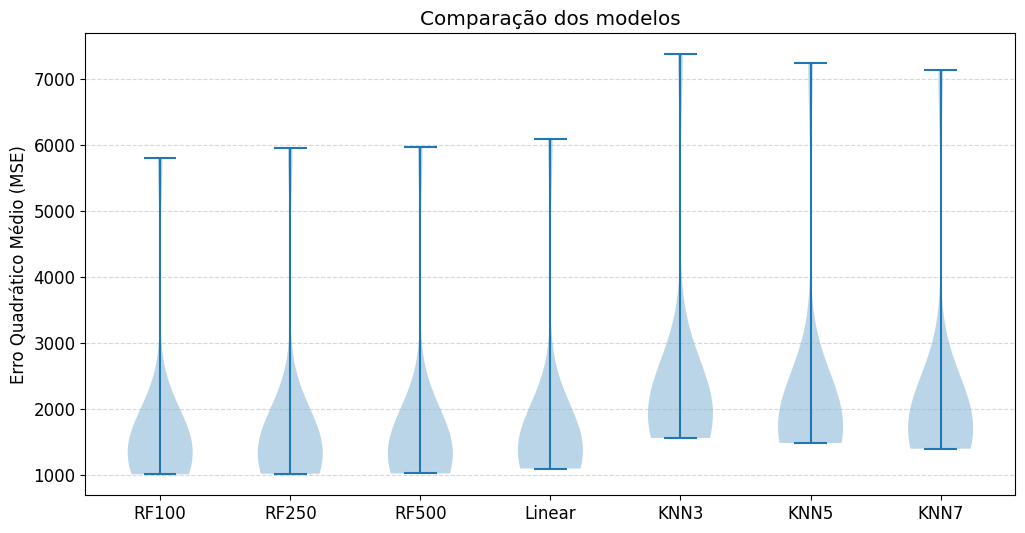

1621.740649498512 1088.2586113507423
1619.777577323528 1124.224320759996
1617.7115719779972 1132.004960930581
1670.0782305740731 1150.2947378564609
2271.43575016716 1332.0939767631924
2084.5095791766294 1338.6291558202709
2048.857731957386 1317.2905877674823


In [ ]:
# result visualization
plt.figure(figsize=(12, 6))
plt.violinplot([
    rf_100_res, rf_250_res, rf_500_res,
    lr_res, knn_3_res, knn_5_res, knn_7_res
])

plt.xticks(
    [1, 2, 3, 4, 5, 6, 7],
    ["RF100", "RF250", "RF500", "Linear", "KNN3", "KNN5", "KNN7"]
)

plt.ylabel("Erro Quadrático Médio (MSE)")
plt.title("Comparação dos modelos")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print(np.mean(rf_100_res), np.std(rf_100_res))
print(np.mean(rf_250_res), np.std(rf_250_res))
print(np.mean(rf_500_res), np.std(rf_500_res))
print(np.mean(lr_res), np.std(lr_res))
print(np.mean(knn_3_res), np.std(knn_3_res))
print(np.mean(knn_5_res), np.std(knn_5_res))
print(np.mean(knn_7_res), np.std(knn_7_res))

In [ ]:
#Escolher o melhor modelo com base na menor média do MSE
resultados = {
    "RF100": np.mean(rf_100_res),
    "RF250": np.mean(rf_250_res),
    "RF500": np.mean(rf_500_res),
    "Linear": np.mean(lr_res),
    "Ridge": np.mean(ridge_res),
    "KNN3": np.mean(knn_3_res),
    "KNN5": np.mean(knn_5_res),
    "KNN7": np.mean(knn_7_res)
}

melhor_modelo = min(resultados, key=resultados.get)
print(f"\nMelhor modelo com base no menor MSE médio: {melhor_modelo}")
print(f"MSE médio do melhor modelo: {resultados[melhor_modelo]:.4f}")


Melhor modelo com base no menor MSE médio: RF500
MSE médio do melhor modelo: 1617.7116


In [ ]:
#Treinar novamente o melhor modelo e calcular métricas adicionais
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

if melhor_modelo == "RF100":
    modelo_final = RandomForestRegressor(n_estimators=100, random_state=42)
elif melhor_modelo == "RF250":
    modelo_final = RandomForestRegressor(n_estimators=250, random_state=42)
elif melhor_modelo == "RF500":
    modelo_final = RandomForestRegressor(n_estimators=500, random_state=42)
elif melhor_modelo == "Linear":
    modelo_final = LinearRegression()
elif melhor_modelo == "Ridge":
    modelo_final = Ridge(alpha=1.0)
elif melhor_modelo == "KNN3":
    modelo_final = KNeighborsRegressor(n_neighbors=3)
elif melhor_modelo == "KNN5":
    modelo_final = KNeighborsRegressor(n_neighbors=5)
else:
    modelo_final = KNeighborsRegressor(n_neighbors=7)

modelo_final.fit(X_train_scaled, y_train)
pred_final = modelo_final.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, pred_final))
mae = mean_absolute_error(y_test, pred_final)
r2 = r2_score(y_test, pred_final)

print("\nResultados do modelo final:")
print(f"Raiz do Erro Quadrático Médio: {rmse:.2f}")
print(f"Erro Absoluto Médio: {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")



Resultados do modelo final:
Raiz do Erro Quadrático Médio: 37.25
Erro Absoluto Médio: 28.87
Coeficiente de Determinação (R²): 0.7706


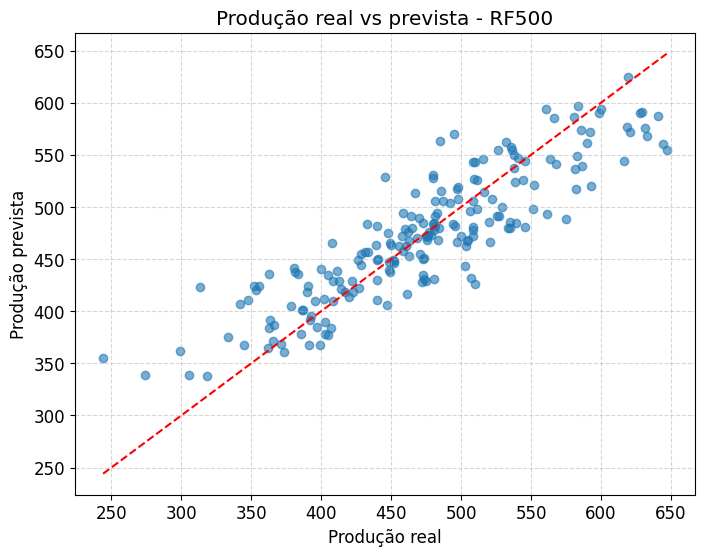

In [ ]:
#Gráfico valores reais vs previstos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_final, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Produção real")
plt.ylabel("Produção prevista")
plt.title(f"Produção real vs prevista - {melhor_modelo}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

##Resumo do trabalho

Neste trabalho foquei-me na previsão da produção de soja na província de Tete, utilizando um conjunto de dados ficticios com variáveis agrícolas e climáticas, como área plantada, precipitação, temperatura, uso de fertilizantes, índice de vegetação, mês de plantio e dias sem chuva. A variável alvo é a produção de soja em toneladas.

Primeiramente, verifiquei a existência de valores em falta e analisei as estatísticas descritivas do conjunto de dados. Não foram encontrados valores nulos, pelo que não foi necessário realizar qualquer tratamento adicional. Como todas as variáveis são numéricas, foram utilizadas diretamente nos modelos. Foi ainda aplicada padronização dos dados com o **StandardScaler**, de forma a garantir que todas as variáveis estão na mesma escala.





###Questão de investigação

É possível prever a produção de soja na província de Tete com base em variáveis agrícolas e climáticas? Qual modelo apresenta melhor desempenho?

### Procedimento

O processo experimental foi repetido quinze vezes, utilizando uma divisão de 80% dos dados para treino e 20% para teste. Foram utilizados três modelos de regressão: **Linear Regression**, **Random Forest** (com 100, 250 e 500 árvores) e **K-Nearest Neighbors (KNN)** (com 3, 5 e 7 vizinhos).

O desempenho dos modelos foi avaliado com base no **Erro Quadrático Médio (MSE)**. Após as repetições, foram calculadas a média e o desvio padrão do erro para cada modelo, e os resultados foram representados através de um **violin plot** para comparar desempenho e estabilidade.

A seguir, selecionei o melhor modelo identificado com base no menor MSE médio, que foi o **Random Forest com 500 árvores (RF500)**. Este modelo foi novamente treinado e avaliado com métricas adicionais: **RMSE**, **MAE** e **R²**.

### Conclusão

Os resultados mostram que é possível prever a produção de soja com base nas variáveis consideradas. O modelo **Random Forest (RF500)** apresentou o melhor desempenho, com menor erro médio. Na avaliação final, obteve-se **RMSE = 37.25**, **MAE = 28.87** e **R² = 0.7706**, indicando uma boa capacidade preditiva.

